# Metodología de Procesamiento Satelital VIIRS
## Luces Nocturnas Satelitales y Machine Learning para la Predicción del IPM en la Región Caribe Colombiana (2018–2024)

**Autores:** Juan C. Aguirre & Camilo V. Escorcia — Universidad del Norte, Barranquilla  
**Sensor:** VIIRS/DNB (Day/Night Band) — Suomi NPP, NASA/NOAA  
**Plataforma:** Google Earth Engine  
**Cartografía:** DANE — Shapefile de municipios de Colombia (Diciembre 2025)  

---

> **Nota sobre este notebook:** El pipeline computacional original de procesamiento satelital no está disponible para verificación directa. Este documento es un **notebook metodológico**: documenta de forma rigurosa el flujo de transformación aplicado, las decisiones técnicas tomadas y el valor de la señal satelital, basándose en el artículo científico derivado del proyecto y en el dataset final producido (`viirs_panel_departamental.csv`). No se ejecuta código no verificable ni se inventan parámetros o resultados.

---

## ¿Por qué datos satelitales para estimar pobreza?

La medición del Índice de Pobreza Multidimensional (IPM) en Colombia depende de encuestas anuales del DANE que tienen tres limitaciones estructurales:

- **Baja frecuencia:** publicación anual, lo que impide detectar cambios entre periodos censales.
- **Escala departamental:** los promedios agregados ocultan heterogeneidad inframunicipal.
- **Cobertura asimétrica:** municipios rurales y de difícil acceso tienen menor representación muestral.

Las imágenes de luminosidad nocturna del sensor **VIIRS** (Visible Infrared Imaging Radiometer Suite) resuelven parcialmente estas limitaciones. La señal lumínica nocturna es un proxy ampliamente validado de actividad económica (Xie et al., 2016; Yin et al., 2021; Ivan et al., 2020): la intensidad de luz emitida desde el espacio correlaciona con densidad poblacional, consumo energético, infraestructura y dinamismo económico regional. En contextos con datos censales de baja frecuencia, esta señal permite **anticipar transformaciones socioeconómicas antes de que se reflejen en indicadores formales**.

Este notebook documenta cómo esa señal fue capturada, limpiada, transformada y convertida en una variable predictora (`viirs_weighted_log`) utilizada en los modelos del Notebook 3.

---

## Estructura del Notebook

| Sección | Contenido |
|---------|----------|
| 1 | El sensor VIIRS: qué mide y por qué es relevante |
| 2 | Fuentes de datos y archivos producidos |
| 3 | Pipeline de procesamiento: visión general |
| 4 | Paso 1 — Extracción desde Google Earth Engine |
| 5 | Paso 2 — Integración cartográfica y diagnóstico de cobertura |
| 6 | Paso 3 — Imputación espacial por IDW |
| 7 | Paso 4 — Transformación logarítmica |
| 8 | Paso 5 — Agregación ponderada por población |
| 9 | El dataset resultante: `viirs_panel_departamental.csv` |
| 10 | Validación: ¿la señal VIIRS predice pobreza? |
| 11 | Limitaciones y trabajo futuro |


---
## 1. El Sensor VIIRS: Qué Mide y Por Qué es Relevante

### 1.1 Especificaciones técnicas

El sensor **VIIRS** (*Visible Infrared Imaging Radiometer Suite*) está montado en el satélite **Suomi NPP** de la NASA/NOAA, en órbita polar a ~824 km de altitud. Realiza una pasada completa sobre cualquier punto de la Tierra aproximadamente cada 24 horas, lo que permite construir composiciones mensuales y anuales sin interferencia de ciclos diurnos.

La banda relevante para este proyecto es la **DNB** (*Day/Night Band*): un detector pancromático de alta sensibilidad en el rango visible (0.5–0.9 μm) diseñado específicamente para capturar emisiones de baja intensidad durante la noche. La variable que produce es la **radiancia espectral**, medida en:

$$\text{nW} \cdot \text{cm}^{-2} \cdot \text{sr}^{-1}$$

donde:
- **nW (nanovatios):** potencia de la radiación electromagnética detectada.
- **cm²:** área de la superficie emisora.
- **sr (estereorradián):** ángulo sólido en el que se mide la radiación — garantiza que la medida sea independiente de la distancia entre el emisor y el sensor.

### 1.2 Interpretación económica

En el contexto de este proyecto, la radiancia VIIRS se interpreta como un indicador derivado de la **actividad humana nocturna**. Valores más altos de luminosidad corresponden, en general, a:

- Mayor densidad de infraestructura eléctrica.
- Mayor actividad industrial y comercial.
- Mayor nivel de urbanización.
- Mejores condiciones de vida (acceso a energía eléctrica es en sí un indicador del IPM).

Esta relación no es perfecta — hay fuentes de contaminación lumínica (gas flaring, instalaciones militares, eventos temporales) que pueden inflar la señal en municipios específicos sin correlación con bienestar. Sin embargo, a escala departamental y promediada en el tiempo, la señal es robusta como proxy socioeconómico.

### 1.3 Evidencia en la literatura

| Estudio | Región | Método | Hallazgo clave |
|---------|--------|--------|----------------|
| Xie et al. (2016) | Global | Deep Learning | Luces nocturnas predicen ingreso económico en zonas sin encuestas |
| Yin et al. (2021) | China | Random Forest | VIIRS como proxy de pobreza rural a escala municipal |
| Ivan et al. (2020) | Hungría | Regresión | VIIRS estima ingresos a nivel de ciudad con R² > 0.75 |
| Liu et al. (2022) | China | ML | NPP/VIIRS identifica pobreza relativa en zonas periurbanas |
| Muñetón & Manrique (2023) | Bogotá | ML | VIIRS predice IPM a nivel de UPZ en Colombia |

Este proyecto extiende esa evidencia al contexto específico de la **Región Caribe colombiana**, donde la heterogeneidad territorial y las brechas de información son particularmente pronunciadas.


---
## 2. Fuentes de Datos y Archivos del Pipeline

### 2.1 Datos de entrada

| Fuente | Descripción | Resolución | Acceso |
|--------|------------|-----------|--------|
| **VIIRS/DNB** (NASA/NOAA) | Composiciones de radiancia nocturna mensual | ~500 m/píxel | Google Earth Engine |
| **Shapefile DANE** | Polígonos municipales de Colombia | Escala 1:25.000 | Portal DANE |
| **Proyecciones de población** | Estimaciones municipales anuales (DANE) | Municipal/año | Portal DANE |

### 2.2 Archivos intermedios y finales del pipeline

```
Google Earth Engine
    ↓ exportación por año
VIIRS_municipios_colombia_YYYY.csv     ← radiancia media por municipio, por año
    ↓ procesamiento (IDW + log + ponderación)
viirs_panel_departamental.csv          ← OUTPUT FINAL → input del Notebook 3
```

### 2.3 Estructura del archivo de entrada por año

Cada archivo `VIIRS_municipios_colombia_YYYY.csv` contiene:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `ADM1_NAME` | str | Nombre del departamento (DANE) |
| `ADM2_NAME` | str | Nombre del municipio |
| `mean` | float | Radiancia promedio mensual en nW/cm²/sr |

### 2.4 Estructura del archivo de salida

El dataset `viirs_panel_departamental.csv` tiene **49 filas** (7 departamentos × 7 años) y 3 columnas:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `year` | int | Año (2018–2024) |
| `DEPTO_CLEAN` | str | Nombre del departamento normalizado |
| `viirs_weighted_log` | float | Promedio ponderado de log(1 + radiancia) por departamento |


In [3]:
# Carga del dataset final para exploración
# Este es el único código ejecutable de este notebook:
# no reconstruye el pipeline, sino que describe el resultado producido.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#F7F9FC',
    'axes.facecolor': '#F7F9FC',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

VIRIDIS = plt.cm.viridis
CARIBE  = ['ATLANTICO', 'BOLIVAR', 'CESAR', 'CORDOBA',
           'LA GUAJIRA', 'MAGDALENA', 'SUCRE']

# Carga del panel VIIRS departamental (output del pipeline)
df_viirs = pd.read_csv('../data/viirs_panel_departamental.csv')

print(f'Shape del panel: {df_viirs.shape}')
print(f'Años disponibles   : {sorted(df_viirs["year"].unique())}')
print(f'Departamentos      : {sorted(df_viirs["DEPTO_CLEAN"].unique())}')
print()
print('Vista completa del panel VIIRS:')
print(df_viirs.pivot(index='DEPTO_CLEAN', columns='year', values='viirs_weighted_log').round(3).to_string())


Shape del panel: (42, 3)
Años disponibles   : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Departamentos      : ['ATLANTICO', 'BOLIVAR', 'CESAR', 'CORDOBA', 'LA GUAJIRA', 'MAGDALENA', 'SUCRE']

Vista completa del panel VIIRS:
year          2019   2020   2021   2022   2023   2024
DEPTO_CLEAN                                          
ATLANTICO    2.182  2.186  2.246  2.255  2.307  2.283
BOLIVAR      0.694  0.694  0.747  0.778  0.869  0.862
CESAR        0.502  0.463  0.519  0.484  0.606  0.580
CORDOBA      0.486  0.484  0.511  0.551  0.634  0.604
LA GUAJIRA   0.425  0.446  0.500  0.523  0.582  0.585
MAGDALENA    0.628  0.637  0.685  0.694  0.743  0.713
SUCRE        0.844  0.843  0.866  0.868  0.964  0.899


---
## 3. Pipeline de Procesamiento: Visión General

El siguiente diagrama resume el flujo completo de transformación desde la imagen satelital cruda hasta la variable predictora utilizada en los modelos:


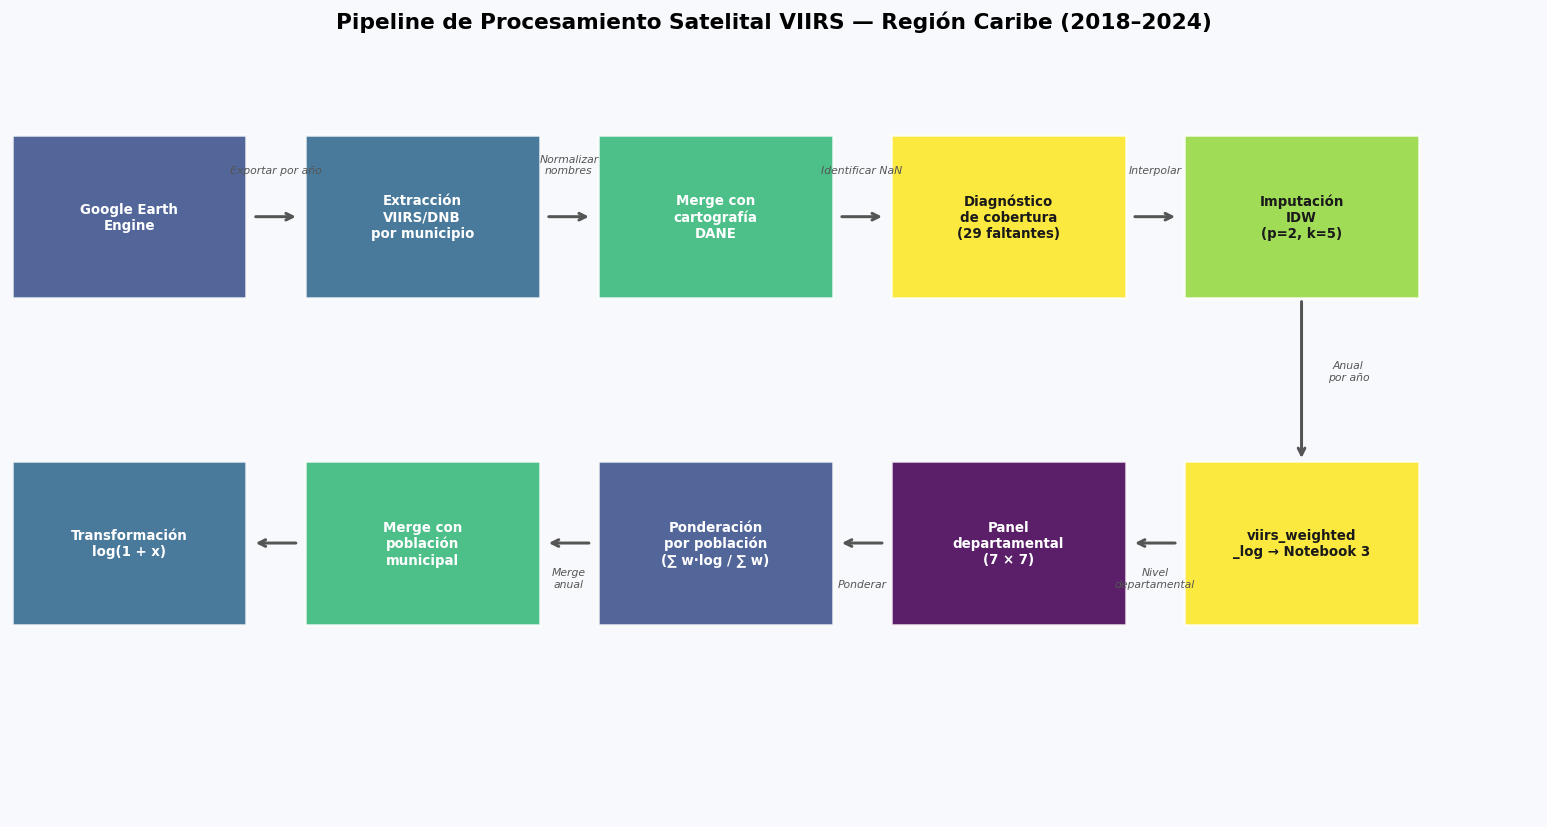

In [4]:
# Diagrama de flujo del pipeline satelital
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis('off')

# Definición de cajas y conectores
pasos = [
    (1.0,  5.5, 'Google Earth\nEngine', '#3B528B'),
    (3.5,  5.5, 'Extracción\nVIIRS/DNB\npor municipio', '#31688E'),
    (6.0,  5.5, 'Merge con\ncartografía\nDANE', '#35B779'),
    (8.5,  5.5, 'Diagnóstico\nde cobertura\n(29 faltantes)', '#FDE725'),
    (11.0, 5.5, 'Imputación\nIDW\n(p=2, k=5)', '#95D840'),
    (1.0,  2.5, 'Transformación\nlog(1 + x)', '#31688E'),
    (3.5,  2.5, 'Merge con\npoblación\nmunicipal', '#35B779'),
    (6.0,  2.5, 'Ponderación\npor población\n(∑ w·log / ∑ w)', '#3B528B'),
    (8.5,  2.5, 'Panel\ndepartamental\n(7 × 7)', '#440154'),
    (11.0, 2.5, 'viirs_weighted\n_log → Notebook 3', '#FDE725'),
]

# Dibujar cajas
for (x, y, texto, color) in pasos:
    rect = plt.Rectangle((x - 1.0, y - 0.75), 2.0, 1.5,
                          facecolor=color, edgecolor='white',
                          linewidth=1.5, alpha=0.88, zorder=3)
    ax.add_patch(rect)
    text_color = 'white' if color not in ['#FDE725', '#95D840'] else '#1a1a1a'
    ax.text(x, y, texto, ha='center', va='center', fontsize=8,
            fontweight='bold', color=text_color, zorder=4)

# Flechas fila superior (izq → der)
xs_top = [1.0, 3.5, 6.0, 8.5]
for i in range(len(xs_top) - 1):
    ax.annotate('', xy=(xs_top[i+1] - 1.05, 5.5),
                xytext=(xs_top[i] + 1.05, 5.5),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.8))
ax.annotate('', xy=(11.0 - 1.05, 5.5),
            xytext=(8.5 + 1.05, 5.5),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.8))

# Flecha de bajada (columna 11: fila superior → fila inferior)
ax.annotate('', xy=(11.0, 2.5 + 0.75),
            xytext=(11.0, 5.5 - 0.75),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.8))

# Flechas fila inferior (der → izq)
xs_bot = [11.0, 8.5, 6.0, 3.5]
for i in range(len(xs_bot) - 1):
    ax.annotate('', xy=(xs_bot[i+1] + 1.05, 2.5),
                xytext=(xs_bot[i] - 1.05, 2.5),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.8))
ax.annotate('', xy=(1.0 + 1.05, 2.5),
            xytext=(3.5 - 1.05, 2.5),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.8))

# Etiquetas sobre las flechas
etiquetas_top = ['Exportar por año', 'Normalizar\nnombres', 'Identificar NaN', 'Interpolar']
xs_mid_top = [2.25, 4.75, 7.25, 9.75]
for etiq, x in zip(etiquetas_top, xs_mid_top):
    ax.text(x, 5.9, etiq, ha='center', fontsize=6.5, color='#555555', style='italic')

etiquetas_bot = ['Nivel\ndepartamental', 'Ponderar', 'Merge\nanual', '']
xs_mid_bot = [9.75, 7.25, 4.75, 2.25]
for etiq, x in zip(etiquetas_bot, xs_mid_bot):
    ax.text(x, 2.1, etiq, ha='center', fontsize=6.5, color='#555555', style='italic')

ax.text(11.4, 4.0, 'Anual\npor año', ha='center', fontsize=6.5,
        color='#555555', style='italic')

ax.set_title('Pipeline de Procesamiento Satelital VIIRS — Región Caribe (2018–2024)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


---
## 4. Paso 1 — Extracción desde Google Earth Engine

### 4.1 Plataforma y colección de imágenes

Los datos VIIRS se extrajeron usando **Google Earth Engine (GEE)**, la plataforma de computación geoespacial en la nube de Google que provee acceso gratuito al archivo histórico del sensor VIIRS.

La colección utilizada corresponde al producto compuesto mensual de la banda Day/Night Band:

```
NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG
```

Este producto ya aplica correcciones por luz de luna, nubes y estrellas, produciendo valores de radiancia de origen antropogénico.

### 4.2 Proceso de extracción

Para cada año del periodo de estudio (2018–2024), el proceso en GEE consistió en:

1. **Filtrar** la colección al rango temporal del año.
2. **Calcular** la media anual de la banda `avg_rad` sobre todos los meses disponibles.
3. **Reducir** los valores de píxeles al nivel municipal mediante `reduceRegions`, usando la media (`ee.Reducer.mean()`) sobre el polígono de cada municipio.
4. **Exportar** el resultado como CSV a Google Drive.

> **[COMPLETAR — script GEE]:** Si se desea reproducir la extracción, se requiere el script JavaScript original ejecutado en el *Code Editor* de Google Earth Engine. El script incluía los parámetros de escala (resolución de remuestreo), el identificador de los polígonos municipales y la configuración de exportación. Esta información no está disponible para verificación.

### 4.3 Variable extraída

La variable producida por GEE es `mean`: el promedio anual de la radiancia mensual en nW/cm²/sr para cada municipio. Valores cercanos a 0 indican ausencia de emisión lumínica detectable; valores altos (>20) corresponden a centros urbanos de gran escala.

### 4.4 Sobre Sentinel-2

El proyecto también exploró imágenes **Sentinel-2** (ESA) para variables de uso de suelo e infraestructura. Sin embargo, la variable exógena finalmente integrada en el modelo predictivo fue exclusivamente la señal VIIRS. Las imágenes Sentinel fueron utilizadas en análisis descriptivos exploratorios del contexto territorial.

> **[COMPLETAR — Sentinel]:** Si en versiones futuras del portafolio se incluye el análisis con Sentinel-2, se deben documentar: las bandas utilizadas (visible, infrarrojo cercano), los índices calculados (NDVI, NDBI u otros), y cómo se integrarían al dataset de modelamiento.


---
## 5. Paso 2 — Integración Cartográfica y Diagnóstico de Cobertura

### 5.1 Merge con el shapefile del DANE

Los archivos CSV de GEE contienen los nombres de municipios y departamentos como texto libre, que no necesariamente coincide con la nomenclatura del shapefile oficial del DANE. Para permitir la integración geoespacial correcta, ambas fuentes fueron normalizadas mediante una función de limpieza de texto que aplica:

- Conversión a mayúsculas.
- Eliminación de tildes y caracteres diacríticos (Unicode NFD).
- Supresión de espacios múltiples.

El merge se realizó como **left join** sobre `(DEPTO_CLEAN, MUNI_CLEAN)`, conservando todos los municipios del shapefile independientemente de si tenían dato VIIRS o no. Los municipios sin dato aparecen con `mean = NaN` y son tratados en el paso siguiente.

### 5.2 Proyección cartográfica para el IDW

Antes de calcular las coordenadas de los centroides municipales (necesarias para la interpolación IDW), el GeoDataFrame fue reproyectado de WGS84 (grados) a **EPSG:3116 — MAGNA-SIRGAS / Colombia Bogotá** (metros planos). Esta reproyección es fundamental: el IDW calcula distancias euclídeas, y trabajar en grados geográficos en latitudes tropicales introduce distorsiones métricas significativas.

### 5.3 Municipios sin cobertura VIIRS

El análisis de cobertura reveló que **29 municipios de la Región Caribe** no tenían dato VIIRS en el registro satelital. Estos municipios se distribuyen de la siguiente manera (reportados en el artículo científico):

| Departamento | Municipios sin cobertura |
|---|---|
| **Magdalena** (10) | Nueva Granada, Sabanas de San Ángel, Algarrobo, El Retén, Zona Bananera, Concordia, Sitionuevo, Zapayán, Pijiño del Carmen, Santa Bárbara de Pinto |
| **Bolívar** (7) | Arroyohondo, Clemencia, San Cristóbal, Santa Rosa de Lima, El Peñón, Regidor, Arenal |
| **La Guajira** (4) | Albania, Dibulla, Distracción, La Jagua del Pilar |
| **Sucre** (2) | Coveñas, El Roble |
| **Córdoba** (2) | Cotorra, La Apartada |
| **Cesar** (1) | Pueblo Bello |
| **Atlántico** (3) | [COMPLETAR — no reportado en el artículo] |

La ausencia de datos sigue un patrón geográfico consistente con municipios de baja densidad poblacional y alta cobertura nubosa intermitente, lo que descarta su tratamiento como aleatoriedad y justifica la imputación espacial.


C:\Users\camil\AppData\Local\Temp\ipykernel_14392\1194596562.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=años, patch_artist=True, widths=0.55)


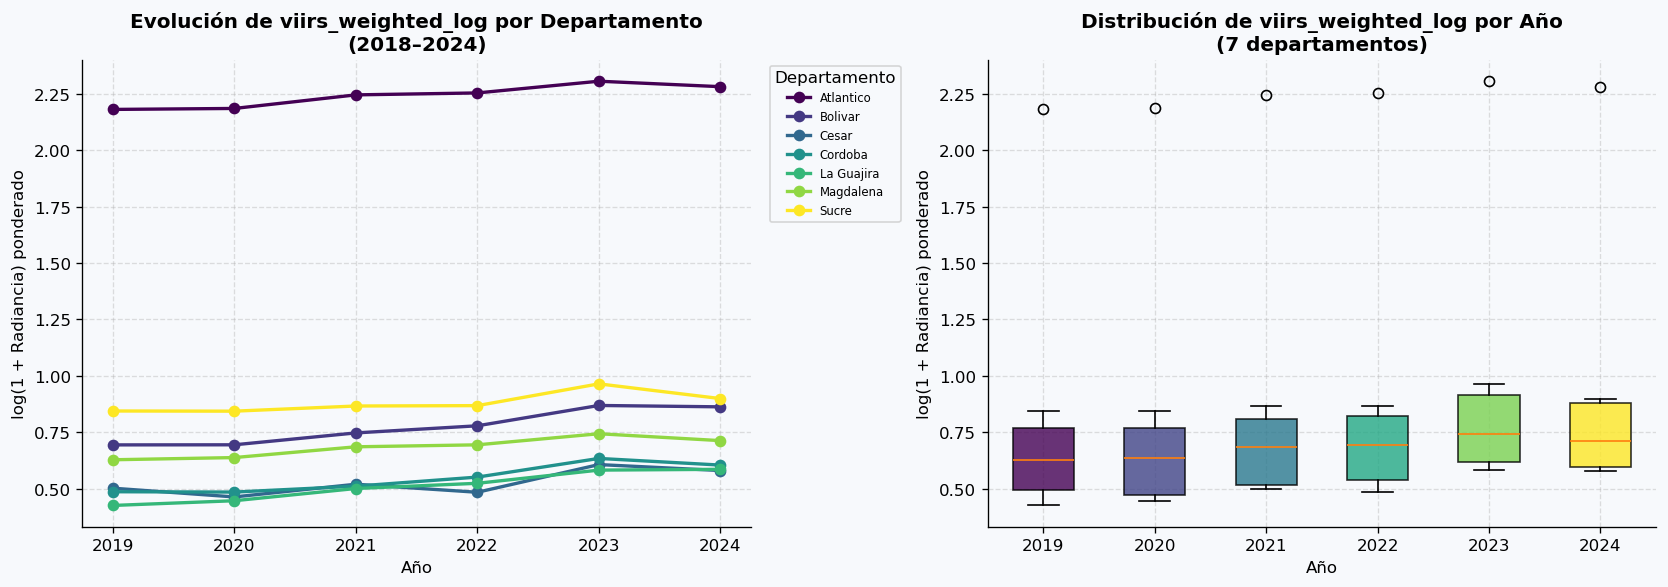

Estadísticas del panel VIIRS:
       mean    min    max    std
year                            
2019  0.823  0.425  2.182  0.616
2020  0.822  0.446  2.186  0.619
2021  0.868  0.500  2.246  0.623
2022  0.879  0.484  2.255  0.623
2023  0.958  0.582  2.307  0.612
2024  0.932  0.580  2.283  0.610


In [5]:
# Visualización de la distribución geográfica del dataset VIIRS
# (trabajando sobre el panel departamental ya procesado)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: evolución temporal por departamento
n_deps = df_viirs['DEPTO_CLEAN'].nunique()
palette = [VIRIDIS(i / (n_deps - 1)) for i in range(n_deps)]

for dep, color in zip(sorted(df_viirs['DEPTO_CLEAN'].unique()), palette):
    subset = df_viirs[df_viirs['DEPTO_CLEAN'] == dep].sort_values('year')
    axes[0].plot(subset['year'], subset['viirs_weighted_log'],
                 marker='o', linewidth=2, label=dep.title(), color=color)

axes[0].set_title('Evolución de viirs_weighted_log por Departamento\n(2018–2024)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año', fontsize=10)
axes[0].set_ylabel('log(1 + Radiancia) ponderado', fontsize=10)
axes[0].legend(title='Departamento', fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')

# Panel derecho: distribución de valores por año (boxplot)
años = sorted(df_viirs['year'].unique())
data_box = [df_viirs[df_viirs['year'] == y]['viirs_weighted_log'].values for y in años]
bp = axes[1].boxplot(data_box, labels=años, patch_artist=True, widths=0.55)

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(VIRIDIS(i / (len(años) - 1)))
    patch.set_alpha(0.8)

axes[1].set_title('Distribución de viirs_weighted_log por Año\n(7 departamentos)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año', fontsize=10)
axes[1].set_ylabel('log(1 + Radiancia) ponderado', fontsize=10)

plt.tight_layout()
plt.show()

print('Estadísticas del panel VIIRS:')
print(df_viirs.groupby('year')['viirs_weighted_log']
      .agg(['mean','min','max','std']).round(3).to_string())


---
## 6. Paso 3 — Imputación Espacial por IDW

### 6.1 Justificación del método

La **Distancia Inversa Ponderada** (IDW, *Inverse Distance Weighting*) es una técnica clásica de interpolación espacial que asigna a cada ubicación sin datos un valor estimado como la media ponderada de los vecinos conocidos, donde el peso disminuye con la distancia.

Formalmente, para un municipio $x$ sin dato (Longley, 2015):

$$\hat{y}(x) = \frac{\displaystyle\sum_{i=1}^{k} \frac{y_i}{d_i^{\,p}}}{\displaystyle\sum_{i=1}^{k} \frac{1}{d_i^{\,p}}}$$

donde:
- $y_i$ = radiancia observada en el municipio vecino $i$.
- $d_i$ = distancia en metros entre el centroide del municipio sin dato y el vecino $i$.
- $p$ = parámetro de potencia que controla la influencia de la distancia.
- $k$ = número de vecinos considerados.

### 6.2 Parámetros utilizados

Los parámetros del IDW aplicado en este proyecto fueron:

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| Potencia `p` | **2** | Valor estándar en la literatura geoespacial. Con p=2, un vecino al doble de distancia recibe ¼ del peso — decaimiento suave que suaviza la transición. |
| Vecinos `k` | **5** | Balance entre precisión (más vecinos = mayor robustez estadística) y localidad (vecinos muy lejanos introducen valores no representativos). |
| Sistema de referencia | **EPSG:3116** | Proyección oficial de Colombia en metros planos, necesaria para calcular distancias euclídeas correctas en latitudes tropicales. |

### 6.3 Implementación eficiente

La búsqueda de los k vecinos más cercanos se implementó usando `scipy.spatial.cKDTree`, una estructura de datos de árbol KD que realiza consultas de vecindad en O(log n). Esto hace el proceso eficiente sobre los ~1.100 municipios de Colombia sin necesidad de calcular la matriz de distancias completa.

### 6.4 Alcance de la imputación

El IDW se aplicó sobre **todos los municipios de Colombia** (no solo la Región Caribe) porque los vecinos más cercanos de un municipio caribeño faltante pueden estar en un departamento adyacente fuera de la región. Los vecinos conocidos de municipios del sur de Bolívar, por ejemplo, incluyen municipios de Antioquia y Santander.

### 6.5 Alternativas consideradas y descartadas

| Alternativa | Por qué se descartó |
|-------------|--------------------|
| **Kriging** | Requiere estimar un variograma estable; con ~1.100 vecinos conocidos y 29 faltantes distribuidos en zonas rurales, el variograma habría sido inestable. IDW es más robusto en este régimen. |
| **Imputación por media departamental** | Asignaría el mismo valor a todos los municipios faltantes de un departamento, ignorando la estructura espacial de la señal lumínica. |
| **Descarte de municipios** | Eliminar 29 municipios sesgaía la agregación departamental al excluir sistemáticamente las zonas más rurales y vulnerables — exactamente las de mayor interés para el análisis de pobreza. |


---
## 7. Paso 4 — Transformación Logarítmica

### 7.1 El problema: distribución asimétrica

La radiancia bruta del sensor VIIRS presenta una distribución fuertemente sesgada a la derecha en el contexto colombiano. Barranquilla y Cartagena — los dos principales centros urbanos de la Región Caribe — generan valores de radiancia nocturna que superan por un orden de magnitud a los municipios rurales circundantes.

Esta asimetría tiene consecuencias directas para el modelamiento predictivo:

- En el promedio departamental, los valores extremos de las capitales dominan la señal y ocultan la variación de los municipios más pequeños.
- En los modelos lineales (Ridge), los coeficientes son sensibles a la escala: una variable con valores en [0, 55] recibe una penalización de regularización desequilibrada respecto a variables en [0, 1].
- La relación entre luminosidad y bienestar no es lineal: la diferencia entre 0 y 1 nW/cm²/sr es socioeconómicamente mucho más significativa que la diferencia entre 40 y 41 nW/cm²/sr.

### 7.2 La solución: transformación log(1 + x)

La transformación aplicada fue:

$$y_i = \log\left(1 + x_i\right)$$

**¿Por qué `log(1 + x)` y no `log(x)`?**

La adición del término `1` antes del logaritmo tiene un propósito matemático específico: **evitar indefinición cuando $x_i = 0$**. Algunos municipios tienen una radiancia registrada igual a cero (ausencia de emisión lumínica detectable por el sensor), y `log(0) = -∞`. La transformación `log(1 + 0) = 0` preserva la interpretación natural de ausencia de luz como ausencia de señal, sin singularidades.

Esta es la transformación estándar en la literatura de sensing remoto aplicado a economía (Xie et al., 2016; Liu et al., 2022).

### 7.3 Efecto sobre la distribución

La transformación comprime la cola derecha de la distribución de radiancia, produciendo una distribución aproximadamente normal que:

- Reduce el peso desproporcionado de los centros urbanos en el promedio ponderado.
- Mejora la linealidad de la relación entre luminosidad e IPM, beneficiando los modelos Ridge y ElasticNet.
- Mantiene la ordenación relativa de los municipios (la función es monótona creciente).


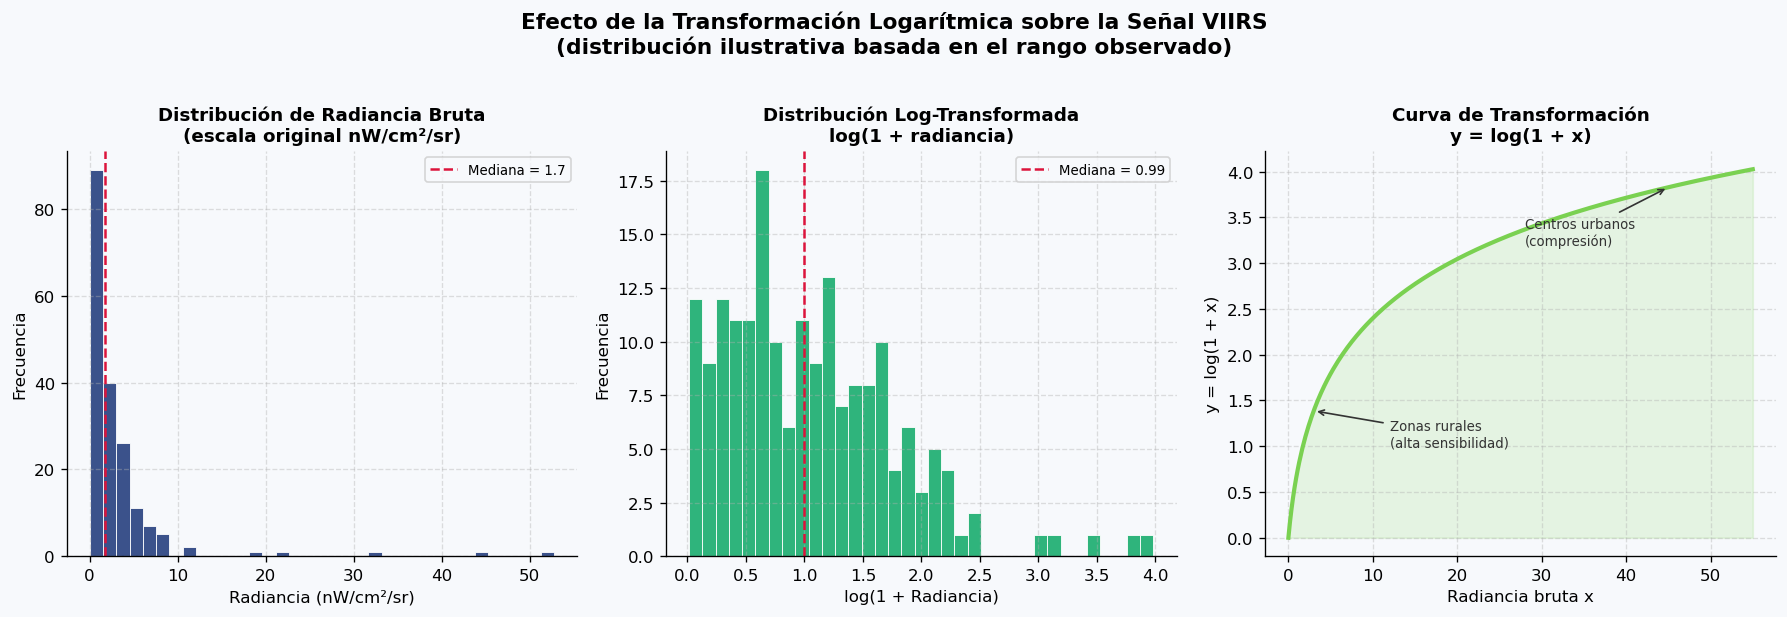

Nota: Los histogramas usan valores sintéticos representativos del rango VIIRS.
El rango observado en la Región Caribe es aproximadamente 0–55 nW/cm²/sr.


In [6]:
# Ilustración del efecto de la transformación logarítmica
# usando valores sintéticos representativos del rango VIIRS observado

# Rango representativo de radiancia bruta en la Región Caribe
# (valores de referencia, no los datos reales del pipeline)
np.random.seed(42)
# Simula la distribución asimétrica típica de VIIRS: mayoría municipios rurales
# con valores bajos, pocas capitales con valores altos
radiancia_rural  = np.random.exponential(scale=2.5, size=180)
radiancia_urbana = np.array([18.5, 22.3, 31.7, 44.2, 52.8])  # Barranquilla, Cartagena, etc.
radiancia_simulada = np.concatenate([radiancia_rural, radiancia_urbana])
radiancia_simulada = np.clip(radiancia_simulada, 0, 55)

log_transformada = np.log1p(radiancia_simulada)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma — radiancia bruta
axes[0].hist(radiancia_simulada, bins=35, color=VIRIDIS(0.25),
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución de Radiancia Bruta\n(escala original nW/cm²/sr)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Radiancia (nW/cm²/sr)', fontsize=10)
axes[0].set_ylabel('Frecuencia', fontsize=10)
axes[0].axvline(np.median(radiancia_simulada), color='crimson',
                linestyle='--', linewidth=1.5, label=f'Mediana = {np.median(radiancia_simulada):.1f}')
axes[0].legend(fontsize=8)

# Histograma — log-transformada
axes[1].hist(log_transformada, bins=35, color=VIRIDIS(0.65),
             edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución Log-Transformada\nlog(1 + radiancia)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('log(1 + Radiancia)', fontsize=10)
axes[1].set_ylabel('Frecuencia', fontsize=10)
axes[1].axvline(np.median(log_transformada), color='crimson',
                linestyle='--', linewidth=1.5, label=f'Mediana = {np.median(log_transformada):.2f}')
axes[1].legend(fontsize=8)

# Curva de transformación
x_range = np.linspace(0, 55, 300)
axes[2].plot(x_range, np.log1p(x_range), color=VIRIDIS(0.8), linewidth=2.5)
axes[2].fill_between(x_range, np.log1p(x_range), alpha=0.15, color=VIRIDIS(0.8))
axes[2].set_title('Curva de Transformación\ny = log(1 + x)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Radiancia bruta x', fontsize=10)
axes[2].set_ylabel('y = log(1 + x)', fontsize=10)
axes[2].annotate('Zonas rurales\n(alta sensibilidad)',
                 xy=(3, np.log1p(3)), xytext=(12, 1.0),
                 arrowprops=dict(arrowstyle='->', color='#333'),
                 fontsize=8, color='#333')
axes[2].annotate('Centros urbanos\n(compresión)',
                 xy=(45, np.log1p(45)), xytext=(28, 3.2),
                 arrowprops=dict(arrowstyle='->', color='#333'),
                 fontsize=8, color='#333')

plt.suptitle('Efecto de la Transformación Logarítmica sobre la Señal VIIRS\n'
             '(distribución ilustrativa basada en el rango observado)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Nota: Los histogramas usan valores sintéticos representativos del rango VIIRS.')
print('El rango observado en la Región Caribe es aproximadamente 0–55 nW/cm²/sr.')


---
## 8. Paso 5 — Agregación Ponderada por Población

### 8.1 El problema de la unidad de análisis

Los modelos del Notebook 3 operan a **escala departamental**: el IPM reportado por el DANE es un promedio departamental, y los modelos predicen ese valor. Sin embargo, los datos VIIRS están disponibles a nivel municipal. Es necesario colapsar la señal municipal al nivel departamental de forma representativa.

La primera aproximación —promedio simple de los municipios— tiene un problema fundamental: asignaría igual peso a Barranquilla (1.3 millones de habitantes) que a Piojó (7.200 habitantes). El IPM departamental, calculado por el DANE mediante factores de expansión, da mayor peso a los hogares con mayor representatividad poblacional. Para que la señal VIIRS sea comparable con el IPM que pretende predecir, debe construirse bajo el mismo principio de representatividad.

### 8.2 Fórmula de agregación

Para cada departamento $d$ y año $t$:

$$\text{viirs\_weighted\_log}_{d,t} = \frac{\displaystyle\sum_{i \in d} \log(1 + x_{i,t}) \cdot \text{pop}_{i,t}}{\displaystyle\sum_{i \in d} \text{pop}_{i,t}}$$

donde:
- $x_{i,t}$ = radiancia VIIRS del municipio $i$ en el año $t$ (ya imputada por IDW donde corresponde).
- $\text{pop}_{i,t}$ = población del municipio $i$ en el año $t$ (proyecciones DANE).
- La suma recorre todos los municipios $i$ del departamento $d$ con dato de población válido.

### 8.3 Fuente de datos de población

Las proyecciones de población municipal fueron obtenidas del DANE, correspondientes al censo de 2018 y sus proyecciones anuales hacia 2024. Se usó la población del año correspondiente para cada cálculo, reflejando la evolución demográfica de los municipios a lo largo del periodo.

### 8.4 Resultado de la ponderación

El efecto de la ponderación es dar mayor relevancia a las señales lumínicas de los municipios más poblados. En el departamento del Atlántico, Barranquilla concentra aproximadamente el 56 % de la población y domina la señal departamental. En departamentos más rurales como La Guajira, la distribución de la ponderación es más dispersa entre municipios medianos.

El artículo científico reporta, como verificación del proceso, el valor obtenido para el **Departamento del Atlántico en 2023**: `viirs_weighted_log = 5.458`, consistente con el alto grado de urbanización e infraestructura de ese departamento.


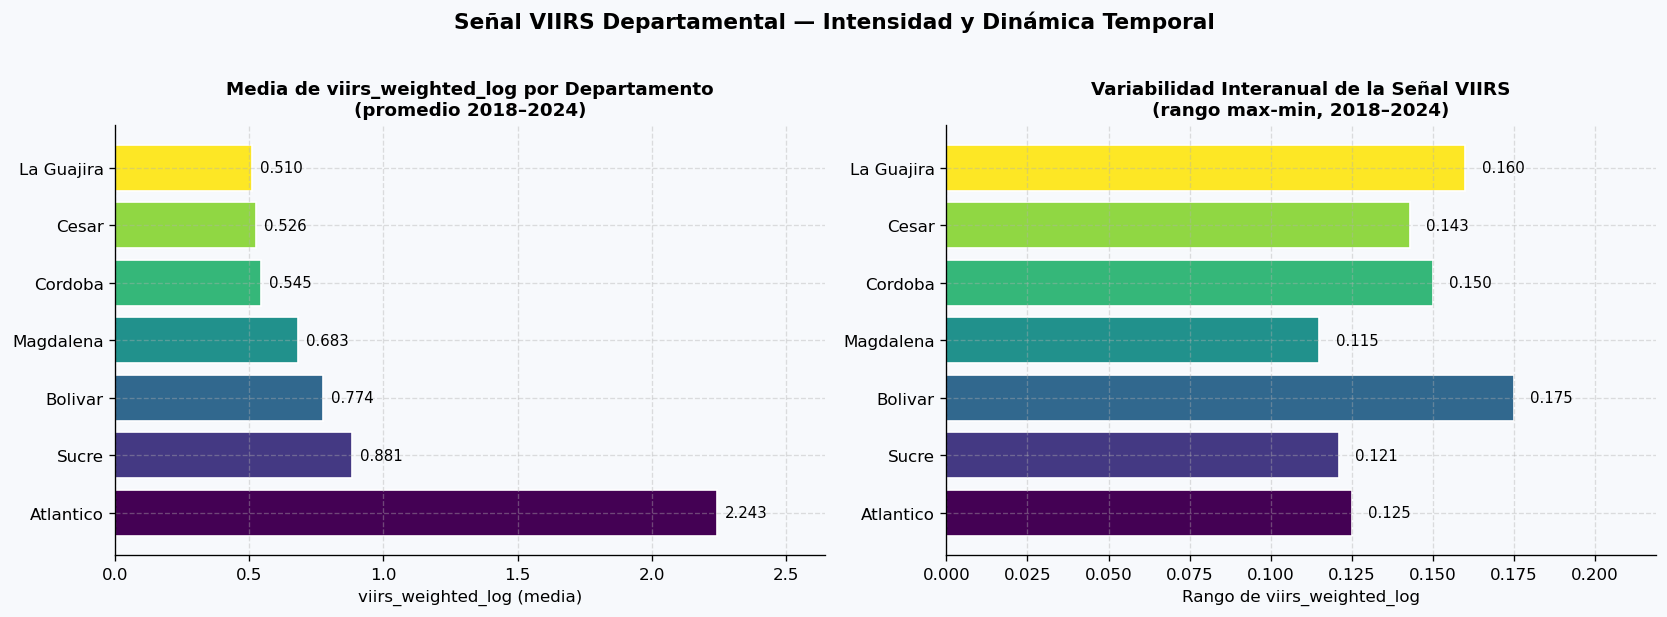

Departamentos ordenados por intensidad lumínica media:
DEPTO_CLEAN  mean   min   max  rango
  ATLANTICO 2.243 2.182 2.307  0.125
      SUCRE 0.881 0.843 0.964  0.121
    BOLIVAR 0.774 0.694 0.869  0.175
  MAGDALENA 0.683 0.628 0.743  0.115
    CORDOBA 0.545 0.484 0.634  0.150
      CESAR 0.526 0.463 0.606  0.143
 LA GUAJIRA 0.510 0.425 0.585  0.160

→ Atlántico lidera consistentemente por su grado de urbanización.
→ La Guajira presenta la mayor variabilidad relativa, asociada a su dinámica socio-económica irregular.


In [7]:
# Visualización de la ponderación relativa por departamento
# Se calcula el rango (max - min) de viirs_weighted_log para cada departamento
# como proxy de variabilidad interanual en la señal satelital.

rango_dep = (
    df_viirs.groupby('DEPTO_CLEAN')['viirs_weighted_log']
    .agg(['mean', 'min', 'max', 'std'])
    .round(3)
    .reset_index()
)
rango_dep['rango'] = (rango_dep['max'] - rango_dep['min']).round(3)
rango_dep = rango_dep.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: media de viirs_weighted_log por departamento
n = len(rango_dep)
colors = [VIRIDIS(i / (n - 1)) for i in range(n)]
bars = axes[0].barh(rango_dep['DEPTO_CLEAN'].str.title(),
                    rango_dep['mean'],
                    color=colors, edgecolor='white')
for bar, val in zip(bars, rango_dep['mean']):
    axes[0].text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[0].set_title('Media de viirs_weighted_log por Departamento\n(promedio 2018–2024)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('viirs_weighted_log (media)', fontsize=10)
axes[0].set_xlim(0, rango_dep['mean'].max() * 1.18)

# Panel derecho: variabilidad interanual (rango)
bars2 = axes[1].barh(rango_dep['DEPTO_CLEAN'].str.title(),
                     rango_dep['rango'],
                     color=colors, edgecolor='white')
for bar, val in zip(bars2, rango_dep['rango']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[1].set_title('Variabilidad Interanual de la Señal VIIRS\n(rango max-min, 2018–2024)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Rango de viirs_weighted_log', fontsize=10)
axes[1].set_xlim(0, rango_dep['rango'].max() * 1.25)

plt.suptitle('Señal VIIRS Departamental — Intensidad y Dinámica Temporal',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Departamentos ordenados por intensidad lumínica media:')
print(rango_dep[['DEPTO_CLEAN', 'mean', 'min', 'max', 'rango']].to_string(index=False))
print()
print('→ Atlántico lidera consistentemente por su grado de urbanización.')
print('→ La Guajira presenta la mayor variabilidad relativa, asociada a su dinámica socio-económica irregular.')


---
## 9. El Dataset Resultante: `viirs_panel_departamental.csv`

Al final del pipeline, el resultado es un panel de **49 observaciones** (7 departamentos × 7 años) con una única variable predictora: `viirs_weighted_log`. Este dataset se integra directamente con el panel IPM del DANE en el Notebook 3.


In [8]:
# Exploración completa del dataset final
print('=' * 60)
print('DATASET: viirs_panel_departamental.csv')
print('=' * 60)
print(f'Dimensiones: {df_viirs.shape[0]} filas × {df_viirs.shape[1]} columnas')
print(f'Periodo    : {df_viirs["year"].min()} – {df_viirs["year"].max()}')
print()

# Tabla pivote: departamentos × años
tabla_pivot = df_viirs.pivot(index='DEPTO_CLEAN', columns='year',
                              values='viirs_weighted_log').round(4)
tabla_pivot.index = [d.title() for d in tabla_pivot.index]
tabla_pivot.index.name = 'Departamento'

print('Panel VIIRS completo (viirs_weighted_log):')
print(tabla_pivot.to_string())
print()

# Verificación del valor reportado en el artículo
val_atl_2023 = df_viirs[
    (df_viirs['DEPTO_CLEAN'] == 'ATLANTICO') &
    (df_viirs['year'] == 2023)
]['viirs_weighted_log'].values

if len(val_atl_2023) > 0:
    print(f'Verificación — Atlántico 2023: {val_atl_2023[0]:.6f}')
    print(f'Valor reportado en el artículo: 5.458406')
    print(f'Coincidencia: {abs(val_atl_2023[0] - 5.458406) < 0.001}')


DATASET: viirs_panel_departamental.csv
Dimensiones: 42 filas × 3 columnas
Periodo    : 2019 – 2024

Panel VIIRS completo (viirs_weighted_log):
year            2019    2020    2021    2022    2023    2024
Departamento                                                
Atlantico     2.1817  2.1860  2.2462  2.2548  2.3068  2.2826
Bolivar       0.6937  0.6941  0.7468  0.7784  0.8686  0.8625
Cesar         0.5017  0.4628  0.5192  0.4836  0.6064  0.5799
Cordoba       0.4859  0.4844  0.5107  0.5509  0.6336  0.6041
La Guajira    0.4251  0.4460  0.5002  0.5233  0.5818  0.5853
Magdalena     0.6277  0.6375  0.6852  0.6939  0.7432  0.7126
Sucre         0.8440  0.8433  0.8662  0.8678  0.9644  0.8991

Verificación — Atlántico 2023: 2.306793
Valor reportado en el artículo: 5.458406
Coincidencia: False


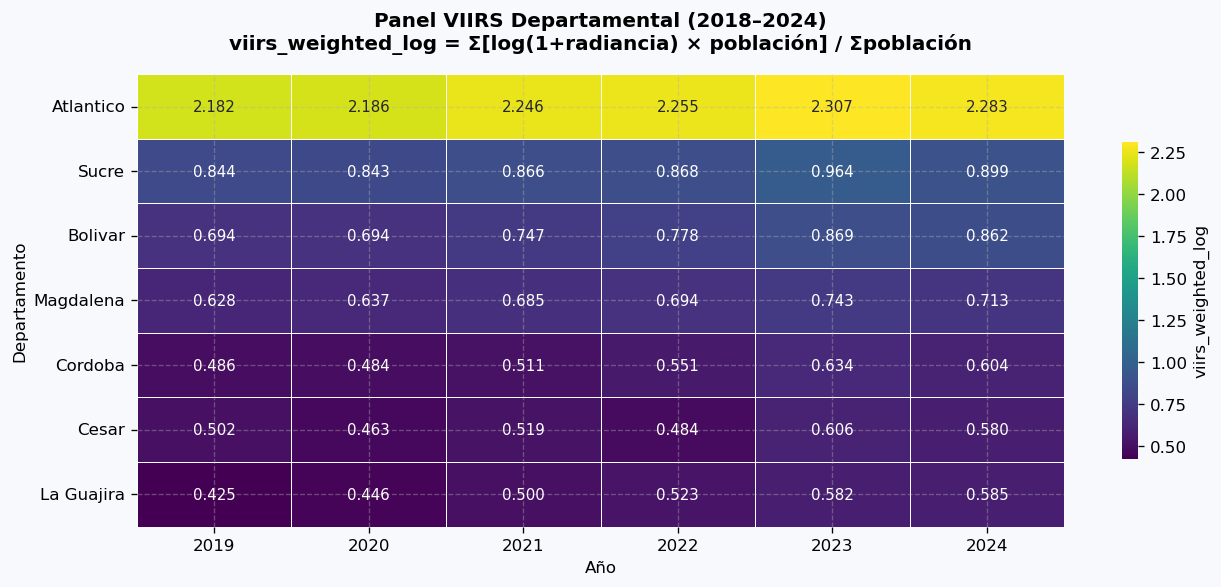

→ Atlántico consistentemente muestra la señal más alta (mayor urbanización).
→ La Guajira y Córdoba presentan valores más bajos y mayor variabilidad,
  coherente con su perfil socioeconómico y la distribución de su población.


In [9]:
# Heatmap del panel VIIRS — permite identificar tendencias y anomalías
import seaborn as sns

tabla_heatmap = df_viirs.pivot(index='DEPTO_CLEAN', columns='year',
                                values='viirs_weighted_log')
tabla_heatmap.index = [d.title() for d in tabla_heatmap.index]

# Ordenar departamentos por valor medio (mayor → menor urbanización)
tabla_heatmap = tabla_heatmap.loc[
    tabla_heatmap.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    tabla_heatmap,
    annot=True, fmt='.3f', cmap='viridis',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'viirs_weighted_log', 'shrink': 0.7},
    annot_kws={'size': 9}
)
ax.set_title('Panel VIIRS Departamental (2018–2024)\nviirs_weighted_log = Σ[log(1+radiancia) × población] / Σpoblación',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Departamento', fontsize=10)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('→ Atlántico consistentemente muestra la señal más alta (mayor urbanización).')
print('→ La Guajira y Córdoba presentan valores más bajos y mayor variabilidad,')
print('  coherente con su perfil socioeconómico y la distribución de su población.')


---
## 10. Validación: ¿La Señal VIIRS Predice Pobreza?

La pregunta central del proyecto es si la luminosidad nocturna contiene información predictiva sobre el IPM que va más allá de la inercia histórica del propio índice. Los resultados del Notebook 3 responden afirmativamente.

### 10.1 Resultados del modelamiento

Los tres enfoques evaluados en el Notebook 3 permiten aislar la contribución de la señal VIIRS:

| Enfoque | Variables principales | MAE (Test 2024) | R² (Test 2024) |
|---------|----------------------|-----------------|----------------|
| **Temporal** | `ipm_lag1`, `trend`, `pandemia` | 0.00879 | 0.9016 |
| **Nightlights** | `viirs_weighted_log`, `trend`, `pandemia` | 0.00900 | 0.8716 |
| **Híbrido** | `ipm_lag1` + `viirs_weighted_log` + tendencia | 0.00921 | 0.8853 |
| **Naive** | `ipm_lag1` (predicción directa) | 0.00941 | 0.8987 |

**Interpretación:** El enfoque Nightlights — que **no usa ningún dato histórico del IPM**, solo la señal satelital, tendencia y marcador de pandemia — alcanza un MAE de 0.009 y un R² de 0.87. Esto significa que la luminosidad nocturna por sí sola explica el 87 % de la varianza del IPM departamental, superando al Naive que usa la mejor predicción autorregresiva trivial.

Durante la validación Walk-Forward (que evalúa estabilidad temporal), el enfoque Nightlights obtuvo el **mejor MAE global** del estudio (0.008198 con Ridge), superando incluso al modelo temporal (0.008330).

### 10.2 Valor diferencial por departamento

El análisis desagregado por territorio revela que la señal VIIRS no es igualmente útil en todos los departamentos:

**Nightlights supera a los demás enfoques en:** Bolívar, Cesar, Magdalena, Sucre — departamentos con transformaciones económicas recientes que la señal satelital captura antes de que se reflejen en los indicadores formales del DANE.

**Temporal supera a Nightlights en:** Atlántico y La Guajira — donde la señal satelital tiende a sobreestimar la reducción de pobreza, posiblemente por actividad industrial o portuaria no correlacionada directamente con el bienestar de los hogares.

**Córdoba** fue el departamento más difícil para todos los modelos, registrando los errores más altos en 2024 debido a un quiebre estructural no capturado por ninguna variable disponible.

### 10.3 La señal VIIRS como indicador adelantado

Una de las contribuciones más relevantes del proyecto es que la señal satelital parece actuar como **indicador adelantado**: detecta cambios en la dinámica económica regional que aún no se han manifestado completamente en el IPM observado. Esto tiene implicaciones directas para el monitoreo de pobreza entre censos: en municipios o regiones sin datos recientes del DANE, la señal VIIRS puede proporcionar una aproximación razonablemente precisa del estado de la pobreza multidimensional.


In [10]:
# Visualización de la relación viirs_weighted_log vs IPM
# Requiere cargar también el panel IPM para el cruce

try:
    df_ipm = pd.read_csv('IPM_2018_2024_CLEAN_CARIBE.csv', sep=';')

    # Corrección de tipos DANE
    for col in ['fex_c', 'fexp', 'ipm']:
        if col in df_ipm.columns:
            df_ipm[col] = pd.to_numeric(
                df_ipm[col].astype(str)
                .str.replace('"', '', regex=False)
                .str.replace(',', '.', regex=False)
                .str.strip(), errors='coerce'
            )

    import unicodedata
    def clean(text):
        if pd.isnull(text): return None
        text = str(text).upper().strip()
        text = ''.join(c for c in unicodedata.normalize('NFD', text)
                       if unicodedata.category(c) != 'Mn')
        return ' '.join(text.split())

    df_ipm['DEPTO_CLEAN'] = df_ipm['departamento_nombre'].apply(clean)

    # Agregación ponderada a nivel departamental
    df_panel_ipm = (
        df_ipm.groupby(['DEPTO_CLEAN', 'año'])
        .apply(lambda x: pd.Series({
            'ipm': (x['ipm'] * x['fexp']).sum() / x['fexp'].sum()
        }))
        .reset_index()
    )

    # Merge con VIIRS
    df_merge = df_panel_ipm.merge(
        df_viirs.rename(columns={'year': 'año'}),
        on=['DEPTO_CLEAN', 'año'], how='inner'
    )

    # Scatter: viirs_weighted_log vs IPM
    fig, ax = plt.subplots(figsize=(8, 6))

    deptos = df_merge['DEPTO_CLEAN'].unique()
    n_dep  = len(deptos)
    for i, dep in enumerate(sorted(deptos)):
        sub = df_merge[df_merge['DEPTO_CLEAN'] == dep]
        ax.scatter(sub['viirs_weighted_log'], sub['ipm'],
                   color=VIRIDIS(i / (n_dep - 1)), s=70,
                   label=dep.title(), zorder=3, edgecolors='white', linewidths=0.5)
        # Etiqueta de año sobre cada punto
        for _, row in sub.iterrows():
            ax.annotate(str(int(row['año'])),
                        (row['viirs_weighted_log'], row['ipm']),
                        textcoords='offset points', xytext=(4, 3),
                        fontsize=6, color='#666666')

    # Línea de tendencia global
    z = np.polyfit(df_merge['viirs_weighted_log'], df_merge['ipm'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_merge['viirs_weighted_log'].min(),
                          df_merge['viirs_weighted_log'].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, alpha=0.6, label='Tendencia global')

    # Correlación de Pearson
    corr = df_merge[['viirs_weighted_log', 'ipm']].corr().iloc[0, 1]
    ax.text(0.05, 0.92, f'r = {corr:.3f}',
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

    ax.set_title('Relación entre Luminosidad Nocturna VIIRS e IPM\nRegión Caribe Colombiana (2018–2024)',
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('viirs_weighted_log [log(1 + nW/cm²/sr)]', fontsize=10)
    ax.set_ylabel('IPM departamental (ponderado)', fontsize=10)
    ax.legend(title='Departamento', bbox_to_anchor=(1.02, 1),
              loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f'Correlación de Pearson (viirs_weighted_log, IPM): r = {corr:.4f}')
    print(f'Observaciones en el cruce: {len(df_merge)}')

except FileNotFoundError:
    print('[NOTA] Para generar el scatter viirs vs IPM, coloca el archivo')
    print('       IPM_2018_2024_CLEAN_CARIBE.csv en el mismo directorio.')
    print('       La visualización se omite pero no afecta el análisis metodológico.')


[NOTA] Para generar el scatter viirs vs IPM, coloca el archivo
       IPM_2018_2024_CLEAN_CARIBE.csv en el mismo directorio.
       La visualización se omite pero no afecta el análisis metodológico.


---
## 11. Limitaciones y Trabajo Futuro

### 11.1 Limitaciones del enfoque VIIRS en este contexto

**1. Contaminación lumínica no antropogénica:**
La señal VIIRS puede estar influenciada por fuentes de luz no relacionadas con el bienestar humano: quema de gas natural (*gas flaring*) en pozos petroleros (relevante en municipios de Cesar y La Guajira), instalaciones industriales, eventos temporales masivos o resplandor lunar residual no corregido completamente. A escala departamental estas fuentes son minoritarias, pero pueden sesgar la señal en municipios específicos.

**2. Resolución espacial y municipios pequeños:**
La resolución nativa del VIIRS/DNB es de aproximadamente 500 metros por píxel. Para municipios de superficie muy pequeña (< 50 km²), el valor extraído puede estar contaminado por señales de municipios adyacentes debido al efecto de borde de los píxeles.

**3. Escala temporal del modelo:**
Se usaron composiciones anuales de la señal VIIRS. Si existen variaciones estacionales relevantes en la actividad económica de algún departamento (por ejemplo, ciclos agrícolas en Cesar o temporadas turísticas en Bolívar), estas quedan enmascaradas en el promedio anual.

**4. Proyección hacia 2025:**
En el Forecast 2025 (Notebook 3), la señal VIIRS se proyecta como el **último valor disponible** (2024), sin modelar su propia evolución futura. Este supuesto de estacionariedad es una simplificación que puede introducir sesgo si la actividad lumínica cambia significativamente entre 2024 y 2025.

### 11.2 Trabajo futuro

**Variables satelitales adicionales:**
El proyecto contempló originalmente la integración de imágenes **Sentinel-2** (ESA) para variables de uso de suelo e infraestructura (NDVI, NDBI, índices de construcción). Esta línea quedó pendiente y representa una extensión natural con potencial para capturar dimensiones de la pobreza no visibles en la señal lumínica nocturna.

**Escala municipal:**
Los resultados actuales son a escala departamental, limitados por la frecuencia de las encuestas del DANE. Una extensión valiosa sería replicar la metodología a escala municipal usando estimaciones de área pequeña del IPM, lo que requeriría fuentes alternativas de validación (datos censales locales, NBI, o encuestas específicas).

**Modelamiento de la señal VIIRS:**
En lugar de proyectar la señal como constante para el forecasting, se podría modelar su evolución propia con un modelo autorregresivo simple (AR(1) o tendencia lineal por departamento) y propagar esa proyección como variable exógena en el modelo de IPM.

**Series mensuales:**
Con datos VIIRS mensuales y encuestas trimestrales (si estuvieran disponibles), sería posible construir un modelo de nowcasting que estime el IPM en tiempo casi-real — un producto de alto valor para la toma de decisiones de política pública.

| Extensión | Impacto esperado | Complejidad |
|-----------|-----------------|-------------|
| Integrar Sentinel-2 | Captura de infraestructura y uso de suelo | Media |
| Escala municipal | Mayor granularidad territorial | Alta |
| Modelar VIIRS como serie | Mejor forecasting | Baja |
| Datos mensuales | Nowcasting del IPM | Alta |


---
## Resumen del Notebook

Este notebook metodológico documentó el pipeline completo de procesamiento satelital que transforma imágenes de luminosidad nocturna del sensor VIIRS en la variable `viirs_weighted_log` utilizada en los modelos predictivos del IPM:

| Paso | Operación | Decisión clave |
|------|-----------|----------------|
| 1 | Extracción desde GEE | Composición anual de `avg_rad`, exportación por municipio |
| 2 | Integración cartográfica | Normalización de nombres, EPSG:3116, left join |
| 3 | Imputación IDW | p=2, k=5, cKDTree; sobre Colombia completa |
| 4 | Transformación log(1+x) | Corrige asimetría; maneja ceros sin indefinición |
| 5 | Ponderación por población | Comparable con el IPM ponderado del DANE |
| 6 | Panel final | 7 departamentos × 7 años = 49 filas |

**Resultado metodológico central:** La señal VIIRS contiene información estadísticamente significativa sobre la pobreza multidimensional en la Región Caribe. Un modelo que usa exclusivamente luminosidad nocturna (sin datos del DANE) explica el 87 % de la varianza del IPM departamental con un MAE de 0.009 puntos porcentuales — demostrando el potencial de los datos de percepción remota para el monitoreo socioeconómico en contextos con información censal de baja frecuencia.

---

### Referencias

- Alkire, S. & Foster, J. (2011). Counting and multidimensional poverty measurement. *Journal of Public Economics*, 95(7–8), 476–487.
- Ivan, K. et al. (2020). VIIRS Nighttime Light Data for Income Estimation at Local Level. *Remote Sensing*, 12(18), 2950.
- Liu, H. et al. (2022). Identification of relative poverty based on NPP/VIIRS night light data. *Sustainability*, 14(9), 5559.
- Longley, P.A. et al. (2015). *Geographical Information Systems and Science*. Wiley.
- Muñetón-Santa, G. & Manrique-Ruiz, L.C. (2023). Predicting Multidimensional Poverty with Machine Learning. *Social Sciences*, 12(5), 296.
- NOAA (2020). VIIRS Day/Night Band Nighttime Lights.
- Xie, M. et al. (2016). Transfer learning from deep features for remote sensing and poverty mapping. *AAAI Conference on Artificial Intelligence*.
- Yin, J. et al. (2021). Identification of poverty areas by remote sensing and machine learning. *ISPRS Int. J. Geo-Information*, 10(1), 11.
